In [7]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def create_animation(index):
    # ==== Load EMG Data ====
    emg_data_path = f"../../data/emg_data/data_{index:02}.csv"
    df = pd.read_csv(emg_data_path)
    time = df["time_stamp"].values
    filtered_1 = df["filtered_1"].values
    filtered_2 = df["filtered_2"].values
    time = time - time[0]

    # ==== Load Video ====
    video_path = f"../../data/emg_data/vid_{index:02}.mp4"
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    video_duration = cap.get(cv2.CAP_PROP_FRAME_COUNT) / fps

    # ==== Matplotlib figure ====
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))
    plt.tight_layout(pad=1.0)

    line1, = ax[0].plot([], [], 'r-', label='Filtered Sensor 1')
    line2, = ax[0].plot([], [], 'b-', label='Filtered Sensor 2')
    ax[0].set_xlim(0, video_duration)
    ax[0].set_ylim(min(filtered_1.min(), filtered_2.min()),
                   max(filtered_1.max(), filtered_2.max()))
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("EMG Value")
    ax[0].legend()

    img_ax = ax[1]
    img_ax.axis('off')
    im = img_ax.imshow(np.zeros((720, 1280, 3), dtype=np.uint8))

    # ==== update ====
    def update(frame):
        ret, frame_img = cap.read()
        if not ret:
            return line1, line2, im
        
        if frame_img.shape[0] > frame_img.shape[1]:
            frame_img = cv2.rotate(frame_img, cv2.ROTATE_90_COUNTERCLOCKWISE)

        t = frame / fps
        idx = np.where(time <= t)[0]
        if len(idx) > 0:
            line1.set_data(time[idx], filtered_1[idx])
            line2.set_data(time[idx], filtered_2[idx])

        im.set_data(cv2.cvtColor(frame_img, cv2.COLOR_BGR2RGB))
        return line1, line2, im
    
    out_path = f'../../data/emg_data/animation_{index:02}.mp4'
    ani = FuncAnimation(fig, update,
                        frames=int(video_duration * fps),
                        interval=1000/fps, blit=True)
    ani.save(out_path, fps=fps)
    cap.release()
    plt.close()
    return out_path

 40%|████      | 4/10 [18:04<27:06, 271.03s/it]


KeyboardInterrupt: 

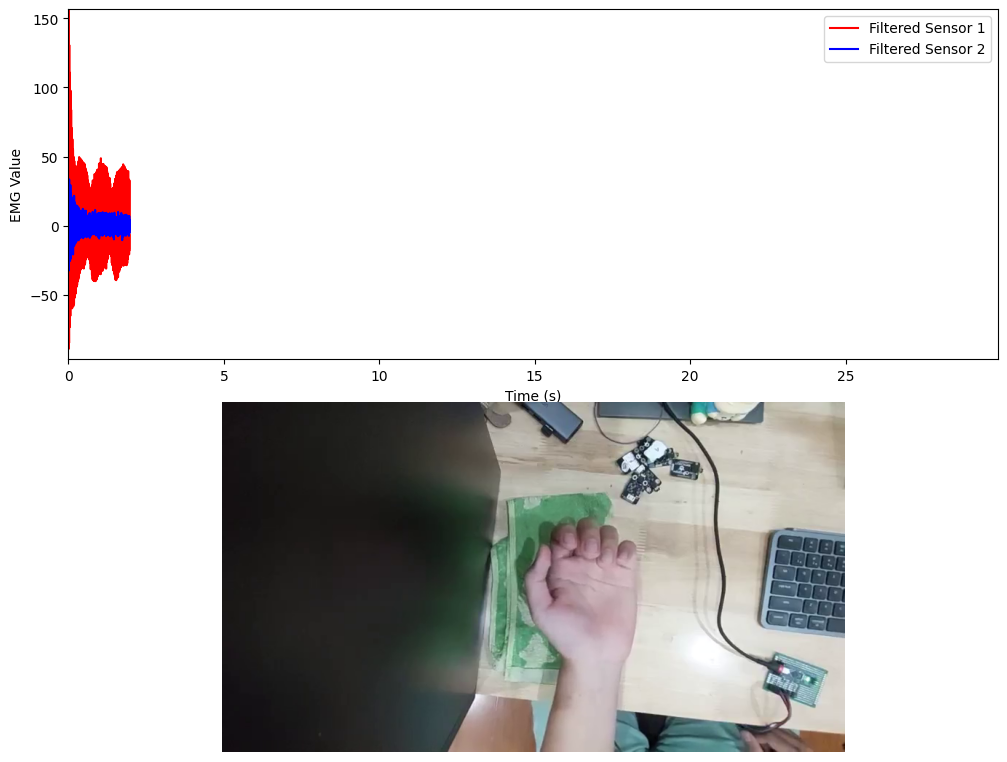

In [8]:
from tqdm.auto import tqdm

animations = {}

for i in tqdm(range(1, 11)):
    animations[i] = create_animation(i)